In [2]:
import xarray as xr
import numpy as np
from subs1_utils import *
import matplotlib.pyplot as plt

import torch
import torch_harmonics.distributed as dist
import torch_harmonics as th

import xesmf as xe

In [3]:
def tropical_weight(lats, trop_lat=10, taper_to=20):
    """
    Cosine taper for tropical heating.

    Parameters
    ----------
    lats : np.ndarray
        1D latitude array (north-to-south)
    trop_lat : float
        Half-width of tropical zone (degrees)
    taper_to : float
        Latitude where tropical heating tapers to zero (degrees)

    Returns
    -------
    w_trop : np.ndarray
        Tropical horizontal weights (0-1)
    """
    w_trop = np.zeros_like(lats, dtype=float)
    mask = np.abs(lats) <= taper_to
    x = np.clip((np.abs(lats[mask]) - trop_lat) / (taper_to - trop_lat), 0, 1)
    w_trop[mask] = np.cos(0.5 * np.pi * x)**2  # 1 at tropics, 0 at taper_to
    return w_trop

In [4]:
jmax = 96
imax = 192
kmax = 26
mw = 63
zw = 63

In [5]:
# Use existing precompute_latitudes function
cost_lg, wlg, lats_rad = precompute_latitudes(jmax)
lats = 90 - 180*lats_rad/np.pi
lons = np.linspace(0.0, 360.0-360.0/imax, imax)
dlatlon = xr.Dataset({"lat": lats, "lon": lons})
delsig, si, sl, sikap, slkap, cth1, cth2, r1b, r2b = bscst(kmax)

In [6]:
sl

array([0.0011232 , 0.00505616, 0.01162568, 0.0216051 , 0.03492528,
       0.05086259, 0.06788822, 0.08335917, 0.09845649, 0.11621708,
       0.13711157, 0.16169278, 0.1906111 , 0.22463262, 0.26465712,
       0.31174359, 0.36723614, 0.43240951, 0.5089765 , 0.59917282,
       0.69574045, 0.78694997, 0.86668817, 0.92940448, 0.97046364,
       0.99253296])

In [7]:
fname='/data/esplab/psinghai/projects/obs_seus/Review/Submit_paper_plots/heating_files/Q1_heating_NH.nc'

In [8]:
ds=xr.open_dataset(fname)

In [9]:
da_comp=ds['Q1'].groupby('clusters').mean()

KeyboardInterrupt: 

In [ ]:
plt.contourf(da_comp.sel(clusters=1,level=500))
plt.colorbar()

In [11]:
pressure=[  1.08486166,   4.88356359,  11.22881978,  20.86758022,
        33.73306385,  49.1263303 ,  65.57076192,  80.51359417,
        95.09554964, 112.2498516 , 132.43108077, 156.17318107,
       184.10433277, 216.96448554, 255.62270116, 301.10180985,
       354.70004899, 417.64863236, 491.60191382, 578.71926301,
       671.9904254 , 760.08638592, 837.10262179, 897.67801905,
       937.33557425, 958.65152444]

In [84]:
vert_struc=np.zeros(26)

vert_struc[0] = 0.0
vert_struc[1] = 0.0
vert_struc[2] = 0.0
vert_struc[3] = 0.0
vert_struc[4] = 0.0
vert_struc[5] = 0.25
vert_struc[6] = 0.5
vert_struc[7] = 0.75
vert_struc[8] = 0.75
vert_struc[9] = 1.0
vert_struc[10] = 1.0
vert_struc[11] = 1.25
vert_struc[12] = 1.25

vert_struc[13] = 1.5
vert_struc[14] = 1.5
vert_struc[15] = 1.75
vert_struc[16] = 1.75

vert_struc[17] = 2.0
vert_struc[18] = 2.0
vert_struc[19] = 2.0
vert_struc[20] = 2.0

vert_struc[21] = 0.75
vert_struc[22] = 0.5
vert_struc[23] = 0.25
vert_struc[24] = 0.0
vert_struc[25] = 0.0


In [85]:
vert_struc

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.25, 0.5 , 0.75, 0.75, 1.  , 1.  ,
       1.25, 1.25, 1.5 , 1.5 , 1.75, 1.75, 2.  , 2.  , 2.  , 2.  , 0.75,
       0.5 , 0.25, 0.  , 0.  ])

In [86]:
rnorm = (vert_struc*delsig).sum()
vert_struc = vert_struc/rnorm

In [87]:
rnorm

1.2711095643842591

In [88]:
vert_struc

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.19667856, 0.39335712, 0.59003568, 0.59003568, 0.78671424,
       0.78671424, 0.98339281, 0.98339281, 1.18007137, 1.18007137,
       1.37674993, 1.37674993, 1.57342849, 1.57342849, 1.57342849,
       1.57342849, 0.59003568, 0.39335712, 0.19667856, 0.        ,
       0.        ])

In [89]:
rnorm

1.2711095643842591

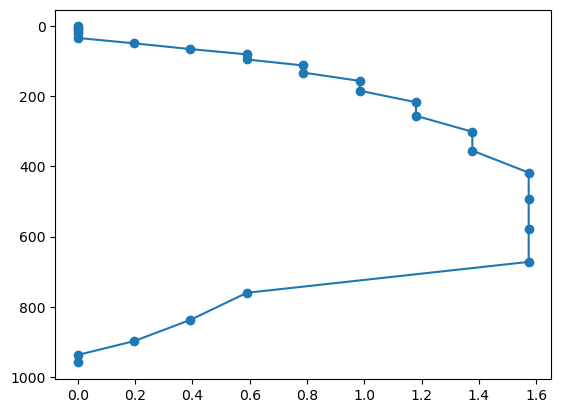

In [90]:
plt.plot(vert_struc,pressure,marker='o')
plt.gca().invert_yaxis()

In [ ]:
tmp=da_comp.sel(lat=slice(10,20),lon=slice(100,140),clusters=1).mean(dim=['lat','lon'])

In [ ]:
tmp

In [ ]:
fig, ax = plt.subplots()
ax.plot(tmp,tmp['level'],marker='o')
ax.set_yscale("log")
ax.invert_yaxis()  
# Custom ticks
ax.set_yticks(tmp['level'].values)
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())  # show as plain integers

ax.set_ylabel("Pressure (hPa)")

arr=tmp
# Example original pressure levels (must match arr!)
# e.g., standard levels from 1000 → 200 hPa
plevs = ds['level'].values

sigma_new = sl

# Interpolate data onto new sigma grid
arr_interp = np.interp(sigma_new, sigma_old[::-1], arr[::-1])  # reverse to ensure increasing x

# Normalize so sum = 1
arr_interp /= arr_interp.sum()

print("Sigma levels:", sigma_new)
print("Interpolated weights:", arr_interp)
print("Check sum:", arr_interp.sum())

edit_arr=arr_interp


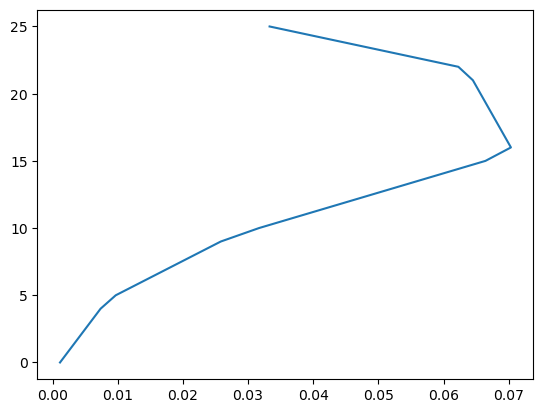

In [98]:
plt.plot(arr_interp,np.arange(0,26))

import numpy as np
from scipy.interpolate import CubicSpline

# Original data on log-pressure levels
arr = np.array([0.18219363, 0.19034941, 0.15895891,
                0.3352764 , 0.11848594, 0.01473571])

# Example original pressure levels (hPa)
plevs = np.array([1000, 850, 700, 500, 300, 200])

# Convert to sigma coordinates
p_surf = plevs[0]  # take surface ~1000 hPa
sigma_old = plevs / p_surf   # decreases with height

# New evenly spaced sigma grid (linear)
n_new = 26
sigma_new = np.linspace(1, sigma_old[-1], n_new)

# Cubic spline interpolation in sigma-space
cs = CubicSpline(sigma_old[::-1], arr[::-1])  # ensure increasing x
arr_smooth = cs(sigma_new)

# Ensure positivity
arr_smooth[arr_smooth < 0] = 0

# Normalize to sum = 1
arr_smooth /= arr_smooth.sum()

print("Sigma levels:", sigma_new)
print("Smoothed weights:", arr_smooth)
print("Check sum:", arr_smooth.sum())

arr_final = arr_smooth[::-1]

plt.plot(arr_final,np.arange(26,0,-1))

import numpy as np
import matplotlib.pyplot as plt

# Original pressure levels (hPa)
plevs = np.array([1000, 850, 700, 500, 300, 200])

# Convert to sigma coordinates (σ = p / p_surface)
p_surf = plevs[0]
sigma_old = plevs / p_surf  # decreases with height

# Define 26 linearly spaced sigma levels from top → bottom
n_new = 26
sigma_new = np.linspace(sigma_old[-1], sigma_old[0], n_new)

# Fit a quadratic polynomial to the data (parabolic shape)
coeffs = np.polyfit(sigma_old, arr, 2)
arr_parab = np.polyval(coeffs, sigma_new)

# Ensure positivity
arr_parab[arr_parab < 0] = 0

# Normalize so sum = 1
arr_parab /= arr_parab.sum()

# Reverse so index 0 = top, index 25 = bottom
arr_final = arr_parab[::-1]

# Plot for comparison
plt.plot(arr, sigma_old, 'o', label='original')
plt.plot(arr_final, np.linspace(sigma_old[0], sigma_old[-1], n_new), '-', label='parabolic 26-level')
plt.gca().invert_yaxis()
plt.xlabel("Weight")
plt.ylabel("Sigma level")
plt.legend()
plt.show()

print("Final array (index 0 = top, 25 = bottom):")
print(arr_final)
print("Sum:", arr_final.sum())


import numpy as np
import matplotlib.pyplot as plt

# 26 linear sigma levels (0 = top, 25 = bottom)
n_new = 26
sigma_linear = np.linspace(0, 1, n_new)  # 0=top,1=bottom

# Parabolic weights: peak at middle (~500 hPa)
weights = 4 * sigma_linear * (1 - sigma_linear)  # simple parabola, max at 0.5

# Optionally scale so sum = 1
weights /= weights.sum()

# Reverse so index 0 = top, 25 = bottom (already 0=top)
arr_final = weights[::-1]

# Plot
plt.plot(arr_final, sigma_linear, '-', label='parabolic 26-level')
plt.gca().invert_yaxis()
plt.xlabel("Weight")
plt.ylabel("Sigma level (0=top,25=bottom)")
plt.legend()
plt.show()

print("Final array:", arr_final)
print("Sum:", arr_final.sum())


import numpy as np
import matplotlib.pyplot as plt

# Original data
arr = np.array([0.18219363, 0.19034941, 0.15895891,
                0.3352764 , 0.11848594, 0.01473571])
plevs = np.array([1000, 850, 700, 500, 300, 200])  # hPa

# Convert pressure to sigma coordinates (linear)
p_surf = plevs[0]
sigma_old = plevs / p_surf  # 1 (surface) → 0.2 (top)

# Reverse arrays so x is increasing for interpolation
sigma_inc = sigma_old[::-1]  # 0.2 → 1
arr_inc = arr[::-1]

# Define 26 linear sigma levels (linear from top → bottom)
n_new = 26
sigma_new = np.linspace(sigma_inc[0], sigma_inc[-1], n_new)

# Linear interpolation
arr_linear = np.interp(sigma_new, sigma_inc, arr_inc)

# Normalize so sum = 1
arr_linear /= arr_linear.sum()

# Reverse so 0 = top, 25 = bottom
arr_final = arr_linear[::-1]

# Plot to check
plt.plot(arr, sigma_old, 'o', label='original')
plt.plot(arr_final, np.linspace(sigma_old[0], sigma_old[-1], n_new), '-', label='linear 26-level')
plt.gca().invert_yaxis()
plt.xlabel("Weight")
plt.ylabel("Sigma level")
plt.legend()
plt.show()

print("Final array (0=top,25=bottom):", arr_final)
print("Sum:", arr_final.sum())


import numpy as np

plevs = np.array([1000, 850, 700, 500, 300, 200])

p_surf = plevs[0]
sigma_old = plevs / p_surf

n_new = 26
sigma_new = np.linspace(1, sigma_old[-1], n_new)

# Linear interpolation
arr_interp = np.interp(sigma_new, sigma_old[::-1], arr[::-1])

# Apply slight smoothing: 3-point moving average
arr_smooth = np.convolve(arr_interp, np.ones(3)/3, mode='same')

# Ensure positivity
arr_smooth[arr_smooth < 0] = 0

# Normalize to sum = 1
arr_smooth /= arr_smooth.sum()

# Optional: reverse so 0 = top, 25 = bottom
arr_final = arr_smooth[::-1]

print("Sigma levels:", sigma_new)
print("Smoothed interpolated weights:", arr_final)
print("Check sum:", arr_final.sum())


# Plot
plt.plot(arr_final, sigma_linear, '-', label='parabolic 26-level')
plt.gca().invert_yaxis()
plt.xlabel("Weight")
plt.ylabel("Sigma level (0=top,25=bottom)")
plt.legend()
plt.show()